<h2>Problem with Weight Initilization</h2>
<li>Vanishing Gradient Problem</li>
<li>Exploding Gradient Problem</li>
<li>Slow Convergence</li>

<h1>What not to follow??</h1>


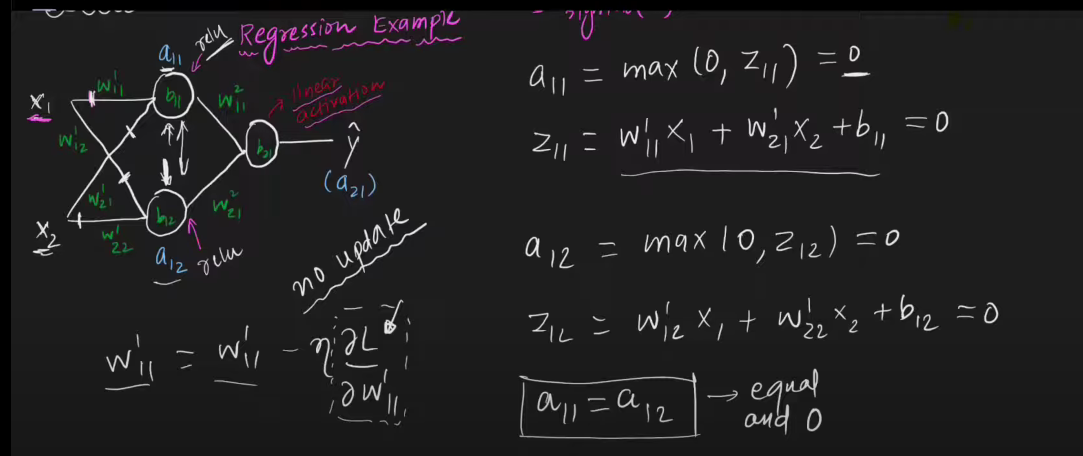



<p> This is case for Relu and Tanh</p>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('ushape.csv', names=['X', 'Y', 'class'], header=None)


In [22]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


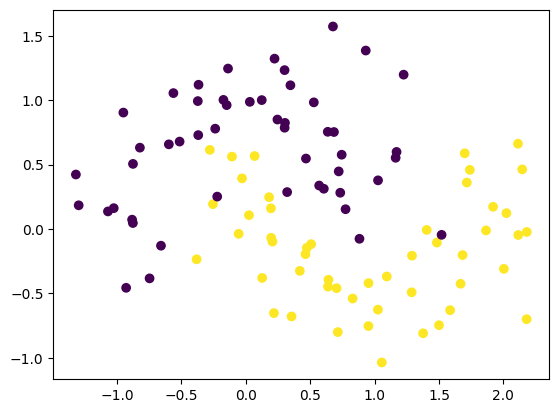

In [24]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [26]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [28]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [29]:
model = Sequential()

model.add(Dense(2,activation='sigmoid',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.summary()

C:\Users\Jatin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Set parameters to 0
model.get_weights()

[array([[ 0.514122  , -1.0235345 ],
        [-0.03539324,  0.17008328]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-1.0326723 ],
        [ 0.52911115]], dtype=float32),
 array([0.], dtype=float32)]

In [34]:
initial_weights = model.get_weights()

In [44]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.zeros(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.zeros(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.zeros(model.get_weights()[3].shape)*0.5

In [46]:
model.set_weights(initial_weights)

In [48]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [50]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [52]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 267ms/step - accuracy: 0.5273 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4570 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5430 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5156 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5234 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4883 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss

In [54]:
model.get_weights()

[array([[-0.47130018, -0.47130018],
        [ 0.5051439 ,  0.5051439 ]], dtype=float32),
 array([-0.01150402, -0.01150402], dtype=float32),
 array([[-0.10308358],
        [-0.10308358]], dtype=float32),
 array([0.01578676], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 947us/step


<Axes: >

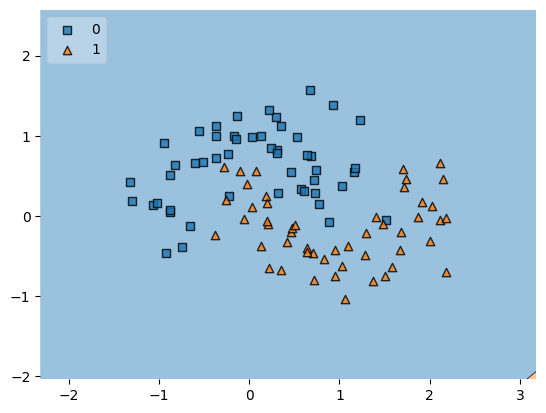

In [56]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

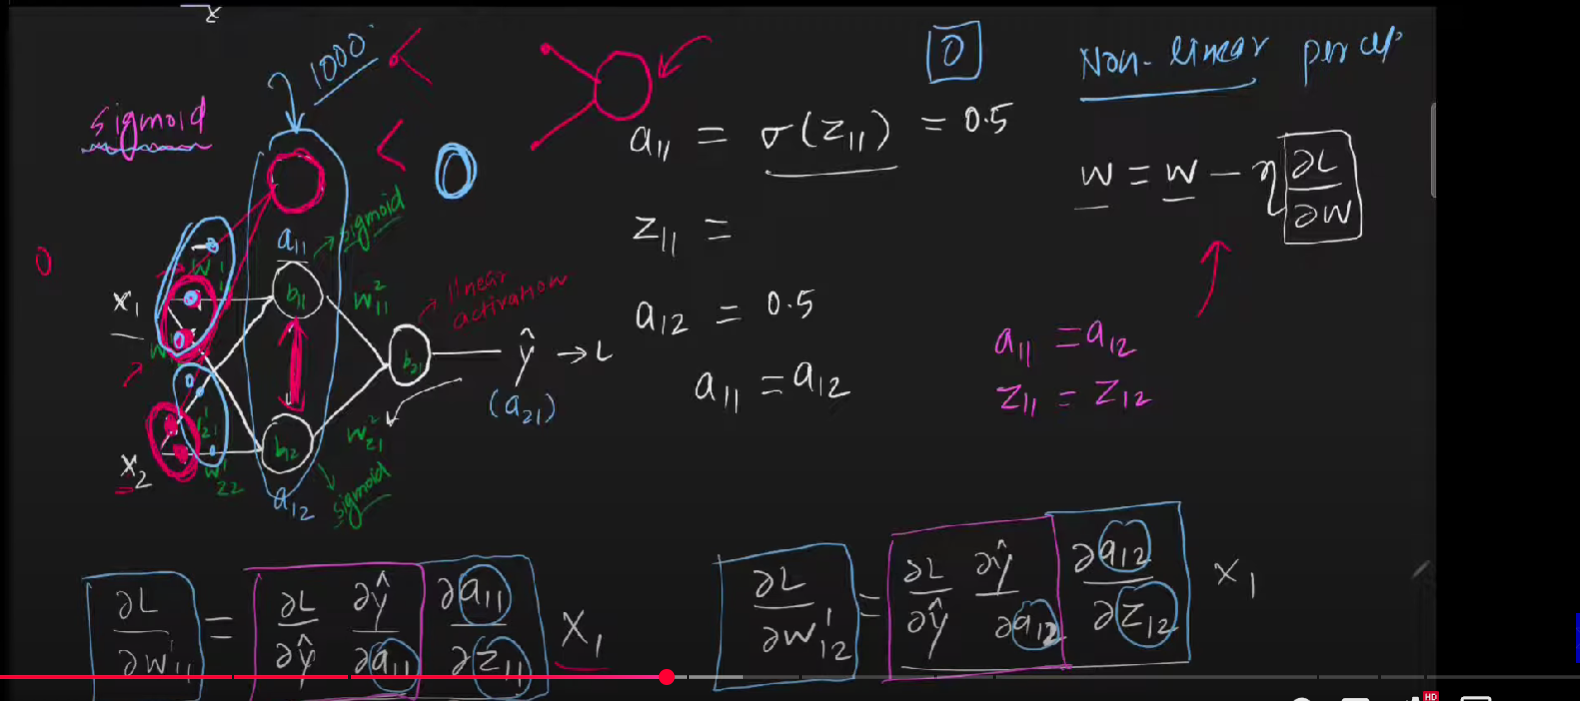

In [59]:
#sigmoid ke case mei kyoki weight initalize krne pr activation to non zero aayega pr actovation saare same aayege so kitni bhi 
# hidden layer lelu wo as a percepton act kregi 

In [61]:
model2 = Sequential()

model2.add(Dense(2,activation='sigmoid',input_dim=2))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

C:\Users\Jatin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [65]:
# Set parameters to 0
model2.get_weights()

[array([[ 0.5793214 , -0.28168756],
        [-0.6445324 ,  0.9427434 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.9345959 ],
        [-0.86283195]], dtype=float32),
 array([0.], dtype=float32)]

In [67]:
initial_weights = model2.get_weights()

In [69]:
initial_weights[0] = np.zeros(model2.get_weights()[0].shape)*0.5
initial_weights[1] = np.zeros(model2.get_weights()[1].shape)*0.5
initial_weights[2] = np.zeros(model2.get_weights()[2].shape)*0.5
initial_weights[3] = np.zeros(model2.get_weights()[3].shape)*0.5

In [71]:
model2.set_weights(initial_weights)

In [73]:
model2.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [75]:
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
history = model2.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.5117 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4961 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4727 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4727 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4922 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5117 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5273 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4688 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss

In [84]:
model2.get_weights()
#weight same hai dekho 

[array([[-0.46942872, -0.46942872],
        [ 0.49312943,  0.49312943]], dtype=float32),
 array([-0.01914799, -0.01914799], dtype=float32),
 array([[-0.11506781],
        [-0.11506781]], dtype=float32),
 array([0.02246061], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 712us/step


<Axes: >

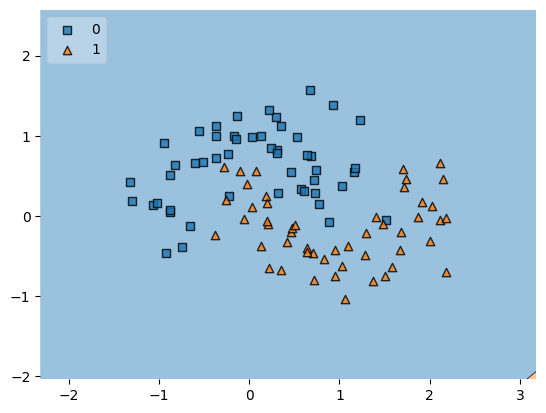

In [81]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

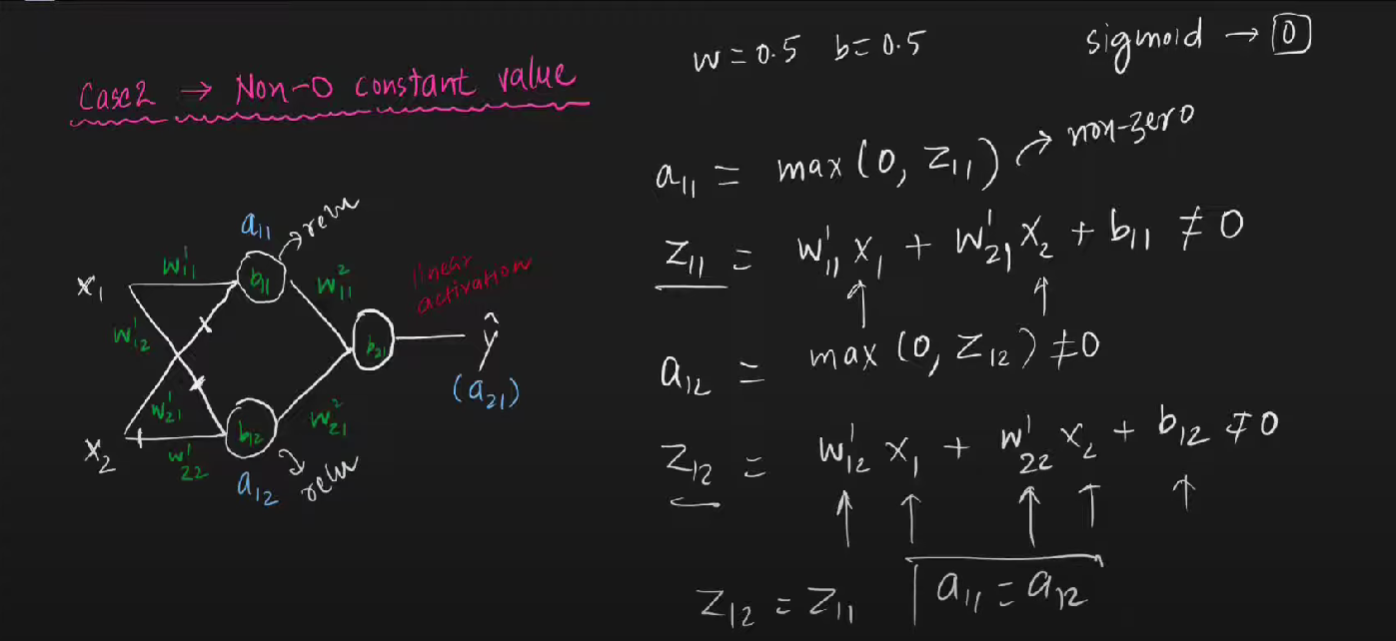

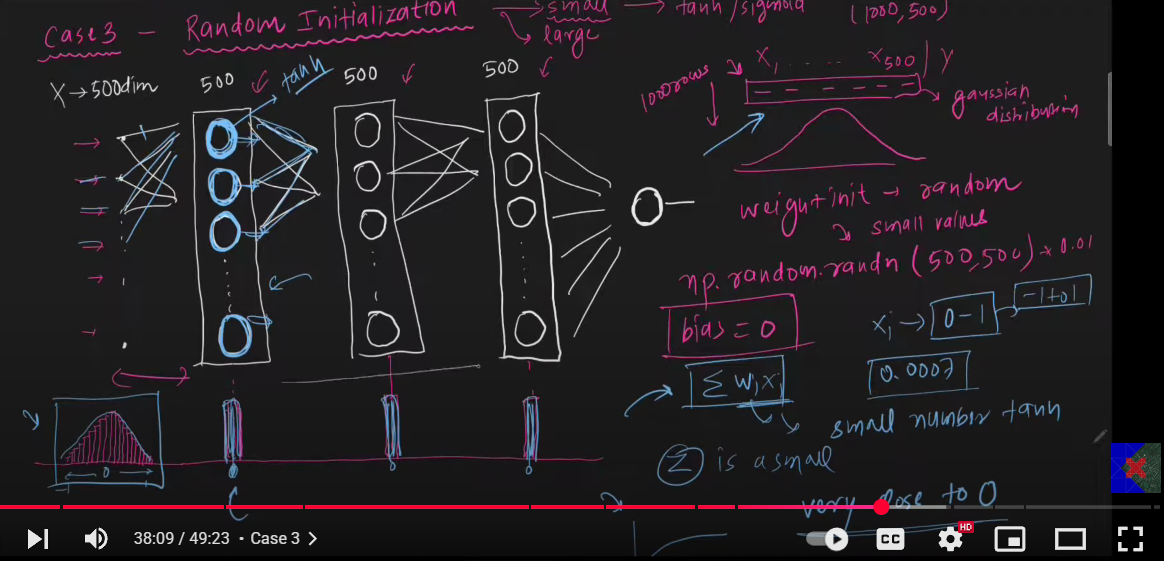

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv('ushape.csv',names=['X','y','class'],header=0)

In [14]:
df.head()

,X,y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [16]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [18]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [20]:
model = Sequential()

model.add(Dense(2,activation='tanh',input_dim=2))
model.add(Dense(2,activation='tanh'))
model.add(Dense(2,activation='tanh'))
model.add(Dense(2,activation='tanh'))

model.summary()

C:\Users\Jatin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │               6 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24 (96.00 B)

 Trainable params: 24 (96.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:

model.get_weights()

[array([[-1.1440805 , -0.6559006 ],
        [-0.37000793, -0.9164817 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.16082442,  0.28503335],
        [ 0.61968744,  0.87287676]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.8208872, 0.6869962],
        [0.5893388, 0.7112572]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.65878063,  0.40714622],
        [ 0.10258937,  0.44007814]], dtype=float32),
 array([0., 0.], dtype=float32)]

In [24]:
initial_weights = model.get_weights()

In [26]:
for i in range(len(initial_weights)):
    if i % 2 == 0:  # weights (even indices: 0,2,4,6,...)
        initial_weights[i] = np.random.randn(*initial_weights[i].shape) * 0.01
    else:           # biases (odd indices: 1,3,5,7,...)
        initial_weights[i] = np.zeros(initial_weights[i].shape)

# Set the new initialized weights
model.set_weights(initial_weights)


In [28]:
model.get_weights()

[array([[0.02525406, 0.00346761],
        [0.00773348, 0.01267685]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.00017904,  0.00149442],
        [ 0.01120007,  0.00630215]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.01110004, -0.01138566],
        [-0.00544198, -0.00173431]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.00486377, -0.00467973],
        [-0.01354548, -0.0170591 ]], dtype=float32),
 array([0., 0.], dtype=float32)]

In [34]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [36]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.8186 - loss: 0.6931 - val_accuracy: 0.8500 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8381 - loss: 0.6931 - val_accuracy: 0.8500 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8537 - loss: 0.6931 - val_accuracy: 0.8500 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8655 - loss: 0.6931 - val_accuracy: 0.8500 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8264 - loss: 0.6931 - val_accuracy: 0.8500 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8381 - loss: 0.6931 - val_accuracy: 0.8500 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8616 - loss: 0.6931 - val_accuracy: 0.8500 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8576 - loss: 0.6931 - val_accuracy: 0.8500 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 5s 553us/step


<Axes: >

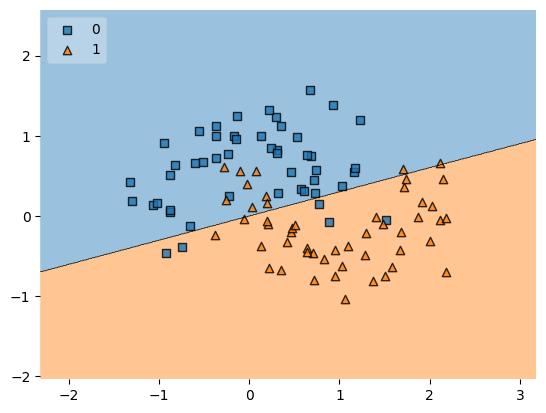

In [40]:
import numpy as np
from mlxtend.plotting import plot_decision_regions

class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model
    
    def predict(self, X):
        probs = self.model.predict(X)
        if probs.shape[1] > 1:     # multiclass/softmax
            return np.argmax(probs, axis=1)
        else:                      # binary/sigmoid
            return (probs > 0.5).astype(int).ravel()

# Wrap your model
clf = KerasClassifierWrapper(model)

# Now plot
plot_decision_regions(X, y.astype('int'), clf=clf, legend=2)


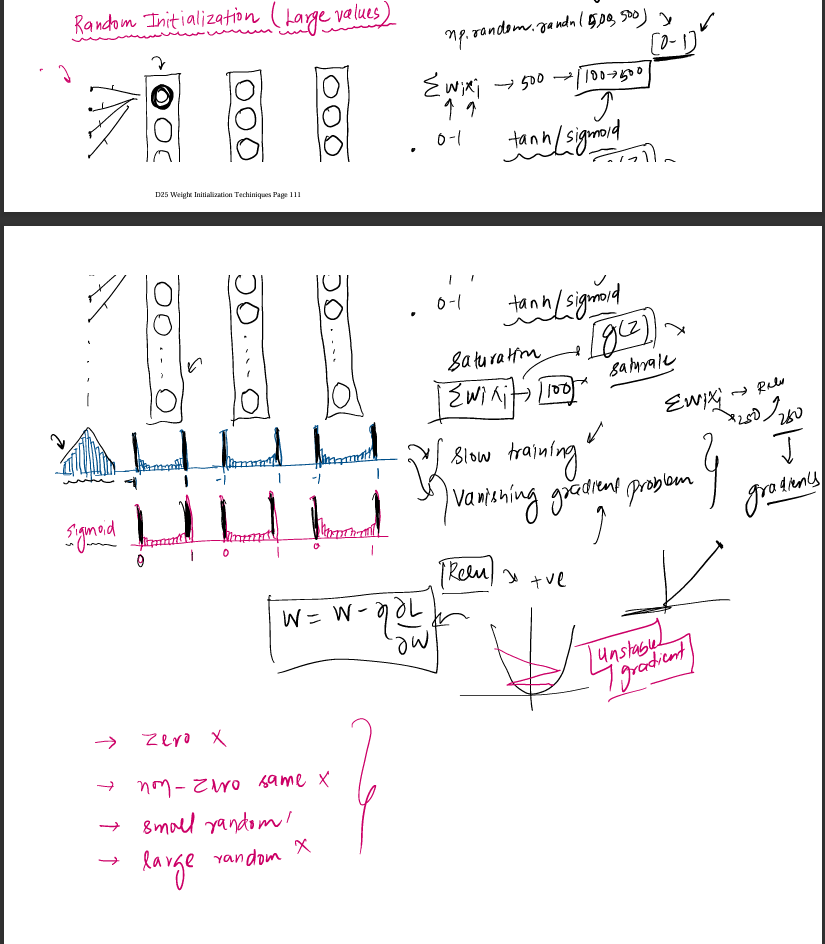